In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_data/egx100.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

In [3]:
df.shape

(1306, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1306 entries, 2015-01-04 to 2020-05-07
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       1306 non-null   float64
 1   open        1306 non-null   float64
 2   high        1306 non-null   float64
 3   low         1306 non-null   float64
 4   vol         1294 non-null   float64
 5   change_pct  1306 non-null   float64
dtypes: float64(6)
memory usage: 71.4 KB


In [5]:
df.head()

,price,open,high,low,vol,change_pct
date,,,,,,
2015-01-04,1095.25,1090.70,1095.67,1088.04,69.38,0.44
2015-01-05,1108.45,1095.72,1110.11,1095.64,99.04,1.21
2015-01-06,1095.09,1106.46,1106.46,1092.67,115.59,-1.21
2015-01-08,1111.65,1096.89,1111.67,1096.89,90.19,1.51
2015-01-11,1110.74,1111.71,1113.37,1110.37,53.21,-0.08


In [6]:
df.tail()

,price,open,high,low,vol,change_pct
date,,,,,,
2020-05-03,1101.29,1134.08,1134.08,1101.29,374.90,-2.89
2020-05-04,1088.93,1101.29,1101.29,1086.47,305.05,-1.12
2020-05-05,1107.07,1088.93,1107.18,1088.93,234.02,1.67
2020-05-06,1118.31,1107.07,1119.80,1107.07,225.18,1.02
2020-05-07,1084.95,1118.31,1119.61,1084.95,320.26,-2.98


In [7]:
#print null count
print(df.isnull().sum())

price          0
open           0
high           0
low            0
vol           12
change_pct     0
dtype: int64


In [8]:
#fill missing values in volume colummn with mean
df['vol'] = df['vol'].fillna(df['vol'].mean())

In [9]:
#Computing daily % return 
df['return'] = df['price'].pct_change() * 100 

In [10]:
#Adding lag features
df['return_lag1'] = df['return'].shift(1)
df['return_lag2'] = df['return'].shift(2)

In [11]:
#Adding rolling features
df['ma_20']         = df['price'].rolling(20).mean()
df['volatility_20'] = df['return'].rolling(20).std()
df['ma_5']          = df['price'].rolling(5).mean()

In [12]:
df['dist_to_ma5'] = (df['price'] / df['ma_5']) - 1
df['dist_to_ma20'] = (df['price'] / df['ma_20']) - 1

In [13]:
# 1. Calculate the Fast (12-day) and Slow (26-day) Exponential Moving Averages (EMA)
ema_12 = df['price'].ewm(span=12, adjust=False).mean()
ema_26 = df['price'].ewm(span=26, adjust=False).mean()

# 2. Calculate the raw MACD line
df['macd'] = ema_12 - ema_26

# 3. Calculate the Signal Line (9-day EMA of the MACD)
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

# 4. Calculate the MACD Histogram (The most useful feature for ML)
# This represents the distance between the MACD and its signal line
df['macd_hist'] = df['macd'] - df['macd_signal']

# What this does: A rising macd_hist means short-term momentum is accelerating upward.

In [14]:
# 1. Calculate the 20-day SMA (Middle Band) and 20-day Standard Deviation
window = 20
sma_20 = df['price'].rolling(window=window).mean()
std_20 = df['price'].rolling(window=window).std()

# 2. Calculate Upper and Lower Bands
upper_band = sma_20 + (std_20 * 2)
lower_band = sma_20 - (std_20 * 2)

# 3. Feature A: Bollinger %B (Where is price relative to the bands?)
# Value of 1.0 = price is touching upper band. Value of 0.0 = touching lower band.
df['bb_pb'] = (df['price'] - lower_band) / (upper_band - lower_band)

# 4. Feature B: Bollinger Bandwidth (How volatile is the market right now?)
# Useful for detecting "squeezes" before explosive moves.
df['bb_bandwidth'] = (upper_band - lower_band) / sma_20

In [15]:
#Adding RSI
delta = df['price'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + gain / loss))

In [16]:
threshold = 0.005

future_return = df['return'].shift(-1)

df['label'] = (future_return > threshold).astype(int)

In [17]:
#Adding rolling features adds NaN rows
df = df.dropna()

In [18]:
df.drop(columns=['price', 'ma_5', 'ma_20'], inplace=True)

In [19]:
# Note for modeling team: price, ma_5, ma_20 are in EGP price scale
# while return, rsi etc. are percentages. Please apply StandardScaler or MinMaxScaler before training.
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1286 entries, 2015-02-03 to 2020-05-07
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   open           1286 non-null   float64
 1   high           1286 non-null   float64
 2   low            1286 non-null   float64
 3   vol            1286 non-null   float64
 4   change_pct     1286 non-null   float64
 5   return         1286 non-null   float64
 6   return_lag1    1286 non-null   float64
 7   return_lag2    1286 non-null   float64
 8   volatility_20  1286 non-null   float64
 9   dist_to_ma5    1286 non-null   float64
 10  dist_to_ma20   1286 non-null   float64
 11  macd           1286 non-null   float64
 12  macd_signal    1286 non-null   float64
 13  macd_hist      1286 non-null   float64
 14  bb_pb          1286 non-null   float64
 15  bb_bandwidth   1286 non-null   float64
 16  rsi            1286 non-null   float64
 17  label          1286 non-null   int64  
dtypes

In [20]:
df.head()

,open,high,low,vol,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,,
2015-02-03,1145.55,1163.11,1145.26,169.83,1.54,1.541954,0.557531,-0.532728,0.884487,0.013930,0.022740,11.783027,11.553765,0.229261,0.865555,0.062206,60.623955,1
2015-02-04,1163.91,1182.69,1163.91,123.32,1.55,1.547775,1.541954,0.557531,0.905913,0.022791,0.035269,13.890739,12.021160,1.869579,1.032397,0.066245,62.741170,0
2015-02-05,1180.97,1181.92,1172.31,105.42,-0.16,-0.158346,1.547775,1.541954,0.840985,0.015186,0.029838,15.234607,12.663849,2.570758,0.988093,0.061131,63.790331,1
2015-02-08,1179.14,1187.09,1179.14,84.19,0.43,0.429145,-0.158346,1.547775,0.797556,0.011669,0.030993,16.517528,13.434585,3.082943,1.001402,0.061812,77.218369,0
2015-02-09,1182.98,1183.48,1178.51,105.49,-0.47,-0.470380,0.429145,-0.158346,0.812436,0.001216,0.023122,16.890102,14.125689,2.764413,0.901460,0.057594,71.962191,1


In [21]:
df.tail()

,open,high,low,vol,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,,
2020-05-03,1134.08,1134.08,1101.29,374.90,-2.89,-2.891330,0.580024,0.237361,1.304758,-0.017774,0.019233,6.179145,-3.858078,10.037224,0.648134,0.129833,63.685886,0
2020-05-04,1101.29,1101.29,1086.47,305.05,-1.12,-1.122320,-2.891330,0.580024,1.346866,-0.023681,0.004790,4.660679,-2.154327,6.815006,0.539926,0.119981,58.375270,1
2020-05-05,1088.93,1107.18,1088.93,234.02,1.67,1.665855,-1.122320,-2.891330,1.333465,-0.004238,0.017099,4.864949,-0.750472,5.615421,0.664909,0.103687,60.315284,1
2020-05-06,1107.07,1119.80,1107.07,225.18,1.02,1.015293,1.665855,-1.122320,1.329195,0.007545,0.023024,5.866187,0.572860,5.293327,0.755694,0.090043,59.738289,0
2020-05-07,1118.31,1119.61,1084.95,320.26,-2.98,-2.983073,1.015293,1.665855,1.405975,-0.013780,-0.008879,3.922585,1.242805,2.679780,0.394214,0.083933,48.883388,0


In [22]:
#return is the same as change_pct so we can drop change_pct
print((df['return'].round(2) == df['change_pct'].round(2)).value_counts())

True     1285
False       1
Name: count, dtype: int64


In [23]:
df.drop(columns=['open', 'high', 'low', 'change_pct'], inplace=True)

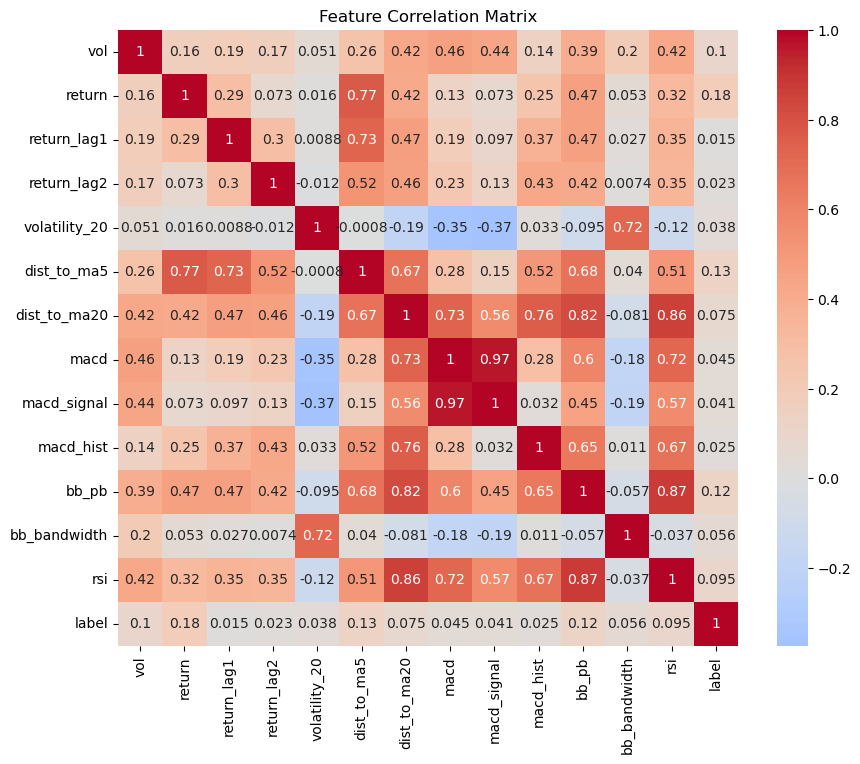

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [25]:
df.corr()

,vol,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
vol,1.000000,0.162960,0.189504,0.168097,0.050838,0.259570,0.422903,0.462561,0.444560,0.142310,0.392422,0.197495,0.420740,0.103141
return,0.162960,1.000000,0.293253,0.072850,0.015796,0.768489,0.415370,0.132753,0.072537,0.249765,0.467131,0.052826,0.317893,0.182838
return_lag1,0.189504,0.293253,1.000000,0.295867,0.008849,0.729126,0.469765,0.186502,0.097306,0.368347,0.466915,0.027204,0.351124,0.014983
return_lag2,0.168097,0.072850,0.295867,1.000000,-0.011590,0.524782,0.462407,0.228831,0.125381,0.429216,0.417522,0.007367,0.350328,0.022767
volatility_20,0.050838,0.015796,0.008849,-0.011590,1.000000,-0.000797,-0.186076,-0.350285,-0.373812,0.033254,-0.094916,0.721117,-0.117765,0.037957
dist_to_ma5,0.259570,0.768489,0.729126,0.524782,-0.000797,1.000000,0.673489,0.275424,0.150948,0.516467,0.677213,0.040140,0.509146,0.127714
dist_to_ma20,0.422903,0.415370,0.469765,0.462407,-0.186076,0.673489,1.000000,0.732543,0.562312,0.763240,0.819857,-0.080548,0.856374,0.074683
macd,0.462561,0.132753,0.186502,0.228831,-0.350285,0.275424,0.732543,1.000000,0.967542,0.283152,0.601666,-0.177219,0.717365,0.045431
macd_signal,0.444560,0.072537,0.097306,0.125381,-0.373812,0.150948,0.562312,0.967542,1.000000,0.031594,0.454483,-0.187688,0.569981,0.040628
macd_hist,0.142310,0.249765,0.368347,0.429216,0.033254,0.516467,0.763240,0.283152,0.031594,1.000000,0.654833,0.011382,0.674099,0.025497


In [26]:
df.drop(columns=['dist_to_ma20', 'macd', 'macd_signal', 'volatility_20'], inplace=True)

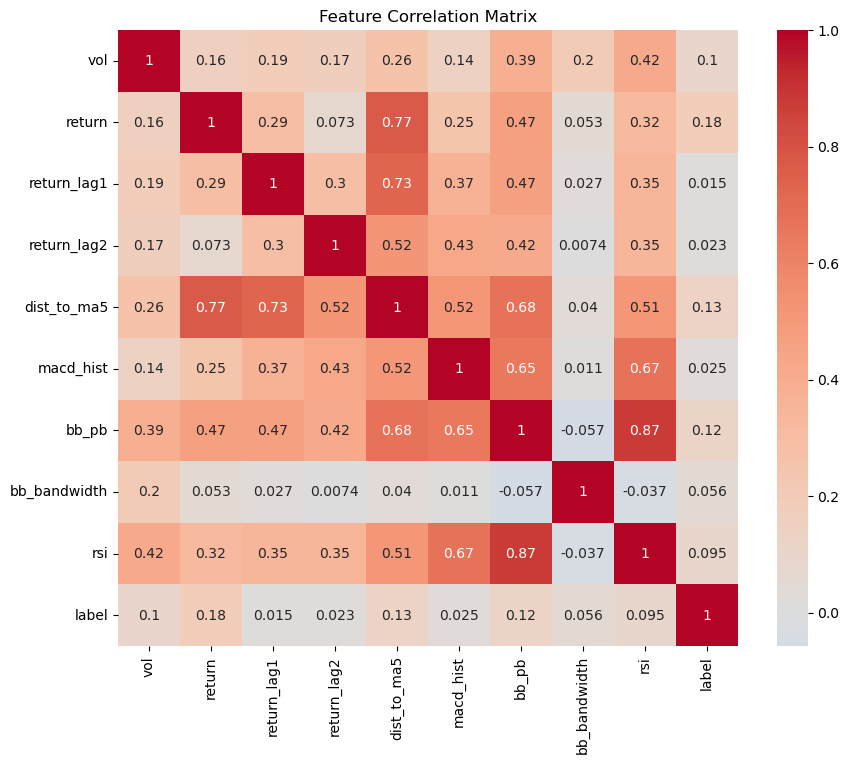

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [28]:
df.corr()

,vol,return,return_lag1,return_lag2,dist_to_ma5,macd_hist,bb_pb,bb_bandwidth,rsi,label
vol,1.000000,0.162960,0.189504,0.168097,0.259570,0.142310,0.392422,0.197495,0.420740,0.103141
return,0.162960,1.000000,0.293253,0.072850,0.768489,0.249765,0.467131,0.052826,0.317893,0.182838
return_lag1,0.189504,0.293253,1.000000,0.295867,0.729126,0.368347,0.466915,0.027204,0.351124,0.014983
return_lag2,0.168097,0.072850,0.295867,1.000000,0.524782,0.429216,0.417522,0.007367,0.350328,0.022767
dist_to_ma5,0.259570,0.768489,0.729126,0.524782,1.000000,0.516467,0.677213,0.040140,0.509146,0.127714
macd_hist,0.142310,0.249765,0.368347,0.429216,0.516467,1.000000,0.654833,0.011382,0.674099,0.025497
bb_pb,0.392422,0.467131,0.466915,0.417522,0.677213,0.654833,1.000000,-0.057284,0.872560,0.122566
bb_bandwidth,0.197495,0.052826,0.027204,0.007367,0.040140,0.011382,-0.057284,1.000000,-0.036967,0.056108
rsi,0.420740,0.317893,0.351124,0.350328,0.509146,0.674099,0.872560,-0.036967,1.000000,0.095493
label,0.103141,0.182838,0.014983,0.022767,0.127714,0.025497,0.122566,0.056108,0.095493,1.000000


In [29]:
sns.set_theme(style="darkgrid", palette="muted")

C:\Users\moata\AppData\Local\Temp\ipykernel_29420\2791296911.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])


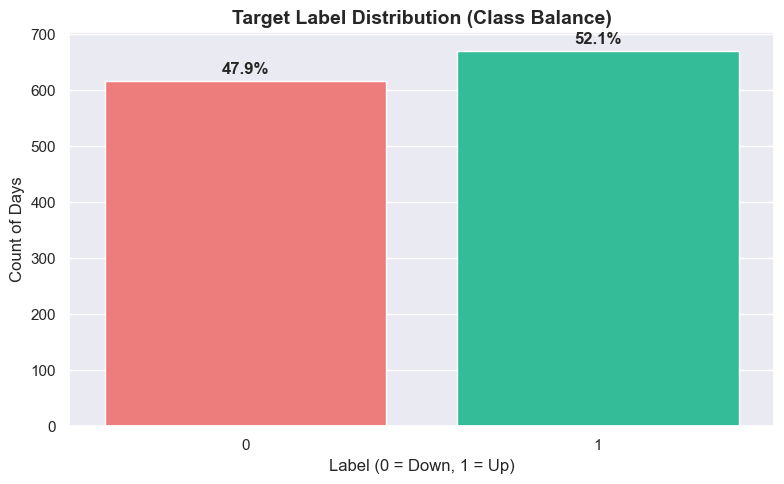

In [30]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])

# Add title and labels
plt.title("Target Label Distribution (Class Balance)", fontsize=14, fontweight='bold')
plt.xlabel("Label (0 = Down, 1 = Up)", fontsize=12)
plt.ylabel("Count of Days", fontsize=12)

# Calculate and add percentage text on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01) # slight offset above bar
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

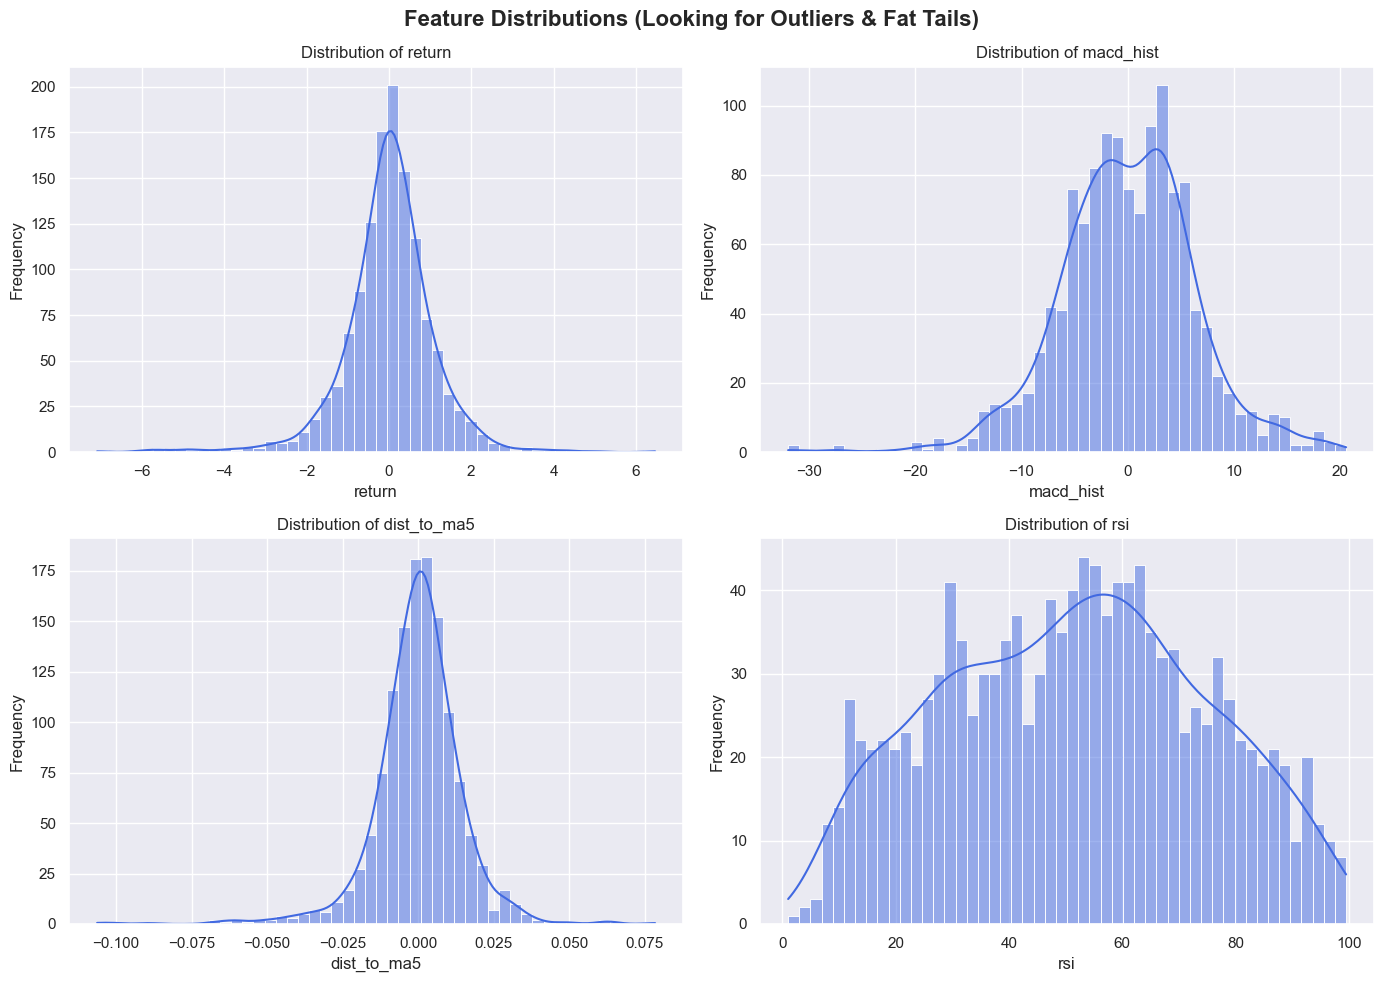

In [31]:
features_to_plot = ['return', 'macd_hist', 'dist_to_ma5', 'rsi']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Distributions (Looking for Outliers & Fat Tails)", fontsize=16, fontweight='bold')

# Flatten axes for easy looping
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(df[feature], kde=True, ax=axes[i], color='royalblue', bins=50)
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_28052\1749860680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_28052\1749860680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_28052\1749860680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], pal

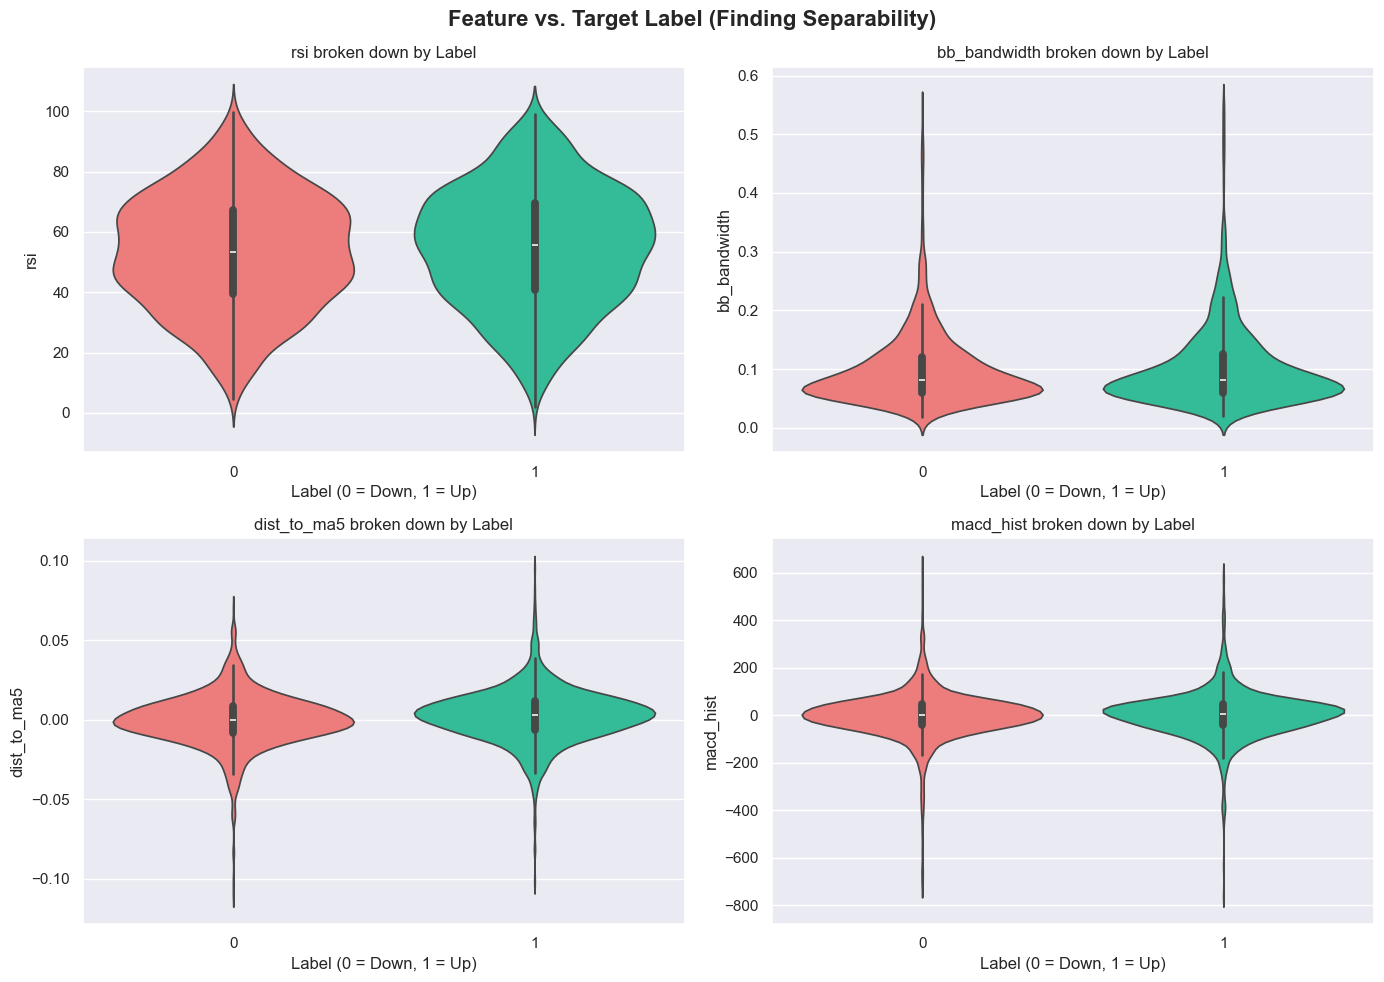

In [244]:
features_to_plot = ['rsi', 'bb_bandwidth', 'dist_to_ma5', 'macd_hist']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature vs. Target Label (Finding Separability)", fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # Violin plot splits the distribution by the label
    sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
    axes[i].set_title(f"{feature} broken down by Label")
    axes[i].set_xlabel("Label (0 = Down, 1 = Up)")

plt.tight_layout()
plt.show()

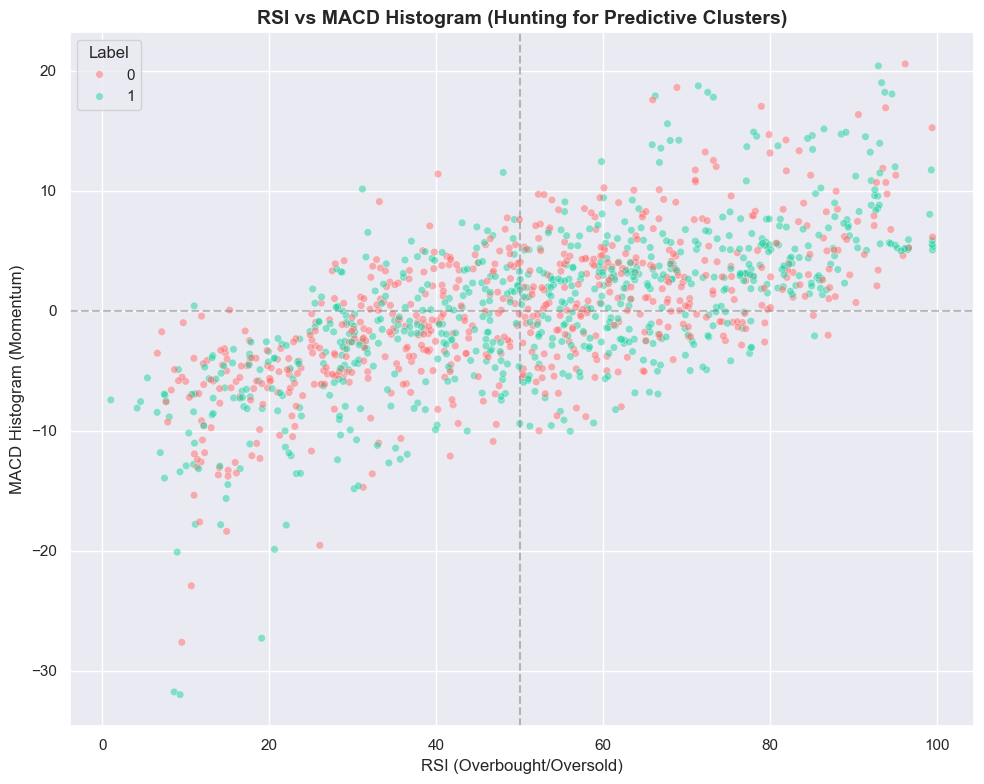

In [32]:
plt.figure(figsize=(10, 8))

# Scatter plot: X is RSI (momentum), Y is MACD (trend), colored by the label
sns.scatterplot(
    data=df, 
    x='rsi', 
    y='macd_hist', 
    hue='label', 
    palette=['#ff6b6b', '#1dd1a1'], # Red for 0, Green for 1
    alpha=0.5, # Makes overlapping dots transparent
    s=30       # Size of dots
)

plt.title("RSI vs MACD Histogram (Hunting for Predictive Clusters)", fontsize=14, fontweight='bold')
plt.xlabel("RSI (Overbought/Oversold)", fontsize=12)
plt.ylabel("MACD Histogram (Momentum)", fontsize=12)
plt.axvline(50, color='gray', linestyle='--', alpha=0.5) # RSI midpoint
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)  # MACD midpoint

plt.legend(title='Label')
plt.tight_layout()
plt.show()

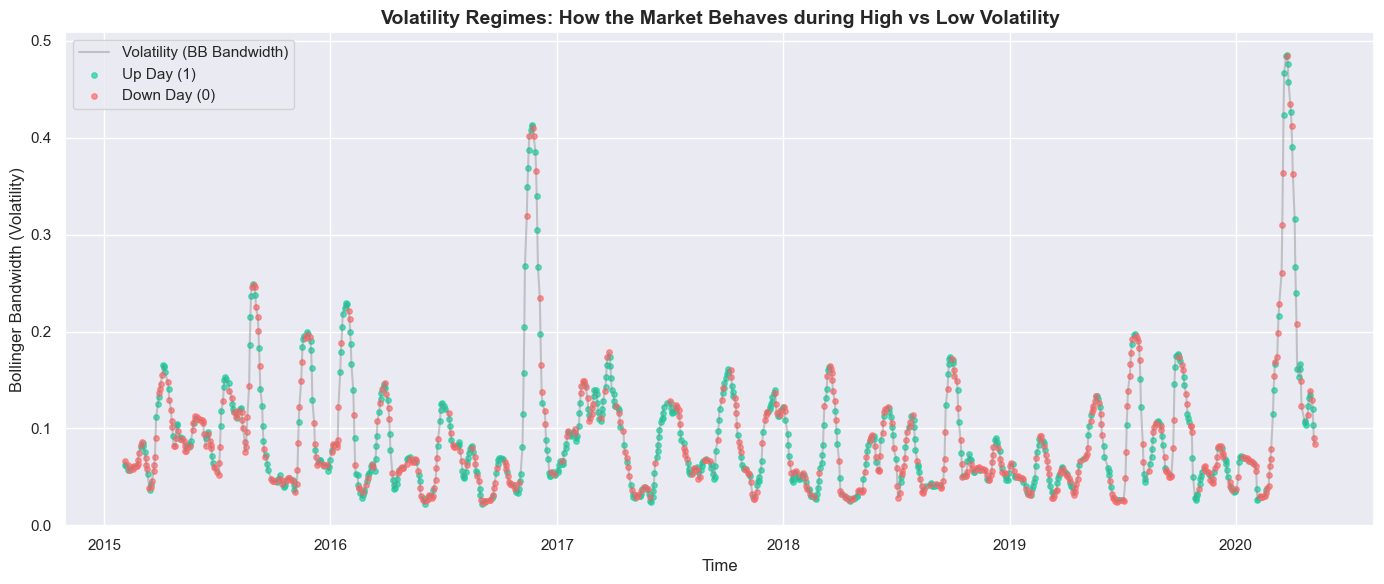

In [33]:
plt.figure(figsize=(14, 6))

# Plot the baseline volatility as a gray line
plt.plot(df.index, df['bb_bandwidth'], color='gray', alpha=0.4, label='Volatility (BB Bandwidth)')

# Overlay Green dots for Up days (Label 1)
up_days = df[df['label'] == 1]
plt.scatter(up_days.index, up_days['bb_bandwidth'], color='#1dd1a1', s=15, alpha=0.7, label='Up Day (1)')

# Overlay Red dots for Down days (Label 0)
down_days = df[df['label'] == 0]
plt.scatter(down_days.index, down_days['bb_bandwidth'], color='#ff6b6b', s=15, alpha=0.7, label='Down Day (0)')

plt.title("Volatility Regimes: How the Market Behaves during High vs Low Volatility", fontsize=14, fontweight='bold')
plt.xlabel("Time", fontsize=12)
plt.ylabel("Bollinger Bandwidth (Volatility)", fontsize=12)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [34]:
df.to_csv('final_data/final_EGX100.csv')